# Speech Emotion Recognition — Kelompok 1
Notebook ini mencakup seluruh pipeline:

1. **Preprocessing Audio** (pembersihan sinyal sebelum ekstraksi fitur)
2. **Ekstraksi Fitur** (domain waktu, domain frekuensi, MFCC, Mel Spectrogram)
3. **Training & Evaluasi Model** (SVM, Random Forest pada 3 skenario fitur, dan CNN)
4. **Ekspor model ke `.pkl`** untuk dipakai pada aplikasi Streamlit

Setiap kali ada `print()` hasil, di atasnya selalu disertai penjelasan singkat
tentang apa yang ditampilkan dan mengapa itu penting — supaya notebook ini
juga berfungsi sebagai bahan pemahaman, bukan cuma output mentah.

**Struktur folder yang dibutuhkan (hasil split 80/20 berbasis aktor):**
```
dataset_split/
├── train/
│   ├── SAD/*.wav
│   ├── HAPPY/*.wav
│   └── ...
└── test/
    ├── SAD/*.wav
    ├── HAPPY/*.wav
    └── ...
```

## 0. Install & Import Library

In [37]:
# Jalankan sekali saja jika library belum terpasang
# !pip install librosa pandas numpy matplotlib seaborn tqdm scikit-learn tensorflow joblib

import os
import glob
import pickle
import joblib
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix
)

sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)
print("Semua library berhasil di-import.")

Semua library berhasil di-import.


## 1. Konfigurasi
Atur lokasi folder dataset hasil split dan parameter preprocessing/ekstraksi fitur di sini.

In [2]:
BASE_DIR     = "dataset_split"   # folder hasil split train/test
SR           = 22050             # sample rate target saat load audio
N_MFCC       = 13                # jumlah koefisien MFCC sesuai tugas
N_MELS       = 128               # jumlah mel-band untuk spectrogram CNN
MAX_PAD_LEN  = 174                # panjang frame tetap mel-spectrogram (~4 detik)
FIXED_DURATION = 4.0               # durasi tetap (detik) hasil preprocessing audio
TOP_DB       = 25                # ambang batas untuk trimming silence (semakin kecil = makin sensitif)

print("Konfigurasi siap.")

Konfigurasi siap.


## 2. Preprocessing Audio
Sebelum fitur diekstrak, sinyal audio mentah perlu "dibersihkan" dan
diseragamkan dulu. Tahap ini penting karena dataset RAVDESS punya rekaman
dengan jeda diam (silence) yang panjangnya berbeda-beda di awal/akhir,
serta level volume yang tidak konsisten antar aktor/rekaman.

Preprocessing yang dilakukan:
1. **Load audio** dan resample ke sample rate seragam (`SR`)
2. **Trim silence**: memotong bagian diam di awal/akhir rekaman, agar fitur
   tidak "terkontaminasi" oleh keheningan yang tidak relevan dengan emosi
3. **Normalisasi amplitudo**: menyamakan skala volume antar file (peak normalization),
   agar model tidak salah belajar bahwa "rekaman lebih kencang = emosi tertentu"
   hanya karena perbedaan microphone/jarak rekam
4. **Penyeragaman durasi**: memotong (jika terlalu panjang) atau menambah
   padding nol (jika terlalu pendek) agar semua file punya panjang yang sama,
   sehingga ukuran Mel Spectrogram konsisten untuk input CNN

In [3]:
# ======================================================================
# FUNGSI: load_and_preprocess_audio
# ----------------------------------------------------------------------
# Tujuan: Memuat satu file audio dan melakukan seluruh tahap preprocessing
# di atas secara berurutan:
#   1. Load + resample          -> librosa.load(sr=SR)
#   2. Trim silence              -> librosa.effects.trim()
#   3. Normalisasi amplitudo     -> dibagi nilai absolut maksimum
#   4. Fix durasi                -> dipotong atau di-pad agar panjang tetap
# Dikembalikan sinyal audio (y) yang sudah "bersih" dan siap diekstrak fiturnya.
# ======================================================================
def load_and_preprocess_audio(filepath, sr=SR, top_db=TOP_DB, duration=FIXED_DURATION):
    # 1. Load audio mentah & resample ke sample rate seragam
    y, sr = librosa.load(filepath, sr=sr)

    # 2. Trim silence di awal/akhir rekaman
    y_trimmed, _ = librosa.effects.trim(y, top_db=top_db)
    if len(y_trimmed) > 0:   # jaga-jaga kalau seluruh sinyal ternyata "diam"
        y = y_trimmed

    # 3. Normalisasi amplitudo ke rentang [-1, 1] berdasarkan nilai peak
    max_val = np.max(np.abs(y))
    if max_val > 0:
        y = y / max_val

    # 4. Samakan durasi semua file menjadi 'duration' detik
    target_len = int(sr * duration)
    if len(y) > target_len:
        y = y[:target_len]                          # potong jika lebih panjang
    else:
        y = np.pad(y, (0, target_len - len(y)))     # tambah padding nol jika lebih pendek

    return y, sr

In [4]:
# ======================================================================
# FUNGSI: explain
# ----------------------------------------------------------------------
# Tujuan: Helper kecil agar setiap kali kita print() suatu hasil, langsung
# disertai penjelasan singkat tentang apa makna hasil tersebut. Dipakai
# berulang kali di seluruh notebook supaya output tidak hanya angka mentah.
# ======================================================================
def explain(title, explanation_text):
    print(f"\n>> {title}")
    print(f"   Penjelasan: {explanation_text}")

### 2.1 Visualisasi Efek Preprocessing
Bandingkan sinyal SEBELUM dan SETELAH preprocessing pada satu contoh file,
agar terlihat jelas efek trimming silence dan normalisasi amplitudo.


>> Perbandingan sinyal sebelum vs setelah preprocessing
   Penjelasan: Sinyal 'Sebelum' biasanya punya jeda diam di awal/akhir dan amplitudo bervariasi. Sinyal 'Setelah' sudah dipotong jeda diamnya, dinormalisasi amplitudonya ke rentang [-1, 1], dan disamakan durasinya.


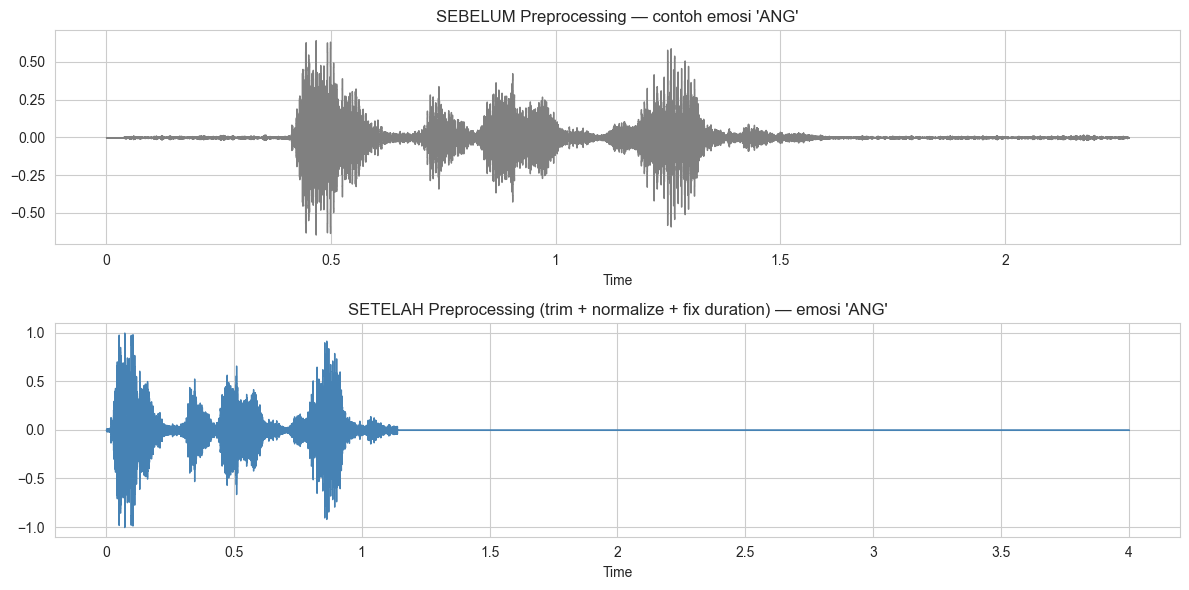


Visualisasi disimpan ke 'preprocessing_before_after.png'


In [5]:
def visualize_preprocessing_effect():
    folder = os.path.join(BASE_DIR, "train")
    wav_files = glob.glob(os.path.join(folder, "*", "*.wav"))
    if not wav_files:
        print("Tidak ada file untuk divisualisasikan.")
        return

    sample_path = wav_files[0]
    label = os.path.basename(os.path.dirname(sample_path))

    y_raw, sr_raw = librosa.load(sample_path, sr=SR)
    y_clean, sr_clean = load_and_preprocess_audio(sample_path)

    explain(
        "Perbandingan sinyal sebelum vs setelah preprocessing",
        "Sinyal 'Sebelum' biasanya punya jeda diam di awal/akhir dan amplitudo "
        "bervariasi. Sinyal 'Setelah' sudah dipotong jeda diamnya, dinormalisasi "
        "amplitudonya ke rentang [-1, 1], dan disamakan durasinya."
    )

    fig, axes = plt.subplots(2, 1, figsize=(12, 6))
    librosa.display.waveshow(y_raw, sr=sr_raw, ax=axes[0], color="gray")
    axes[0].set_title(f"SEBELUM Preprocessing — contoh emosi '{label}'")

    librosa.display.waveshow(y_clean, sr=sr_clean, ax=axes[1], color="steelblue")
    axes[1].set_title(f"SETELAH Preprocessing (trim + normalize + fix duration) — emosi '{label}'")

    plt.tight_layout()
    plt.savefig("preprocessing_before_after.png", dpi=150)
    plt.show()
    print("\nVisualisasi disimpan ke 'preprocessing_before_after.png'")

visualize_preprocessing_effect()

## 3. Ekstraksi Fitur

### 3.1 Fungsi-fungsi ekstraksi fitur
Fungsi-fungsi ini dijalankan pada sinyal audio yang SUDAH dipreprocessing
pada tahap sebelumnya.

In [6]:
# ======================================================================
# FUNGSI: extract_label_from_filename
# ----------------------------------------------------------------------
# Tujuan: Mengambil nama folder (= label emosi) dari path file, karena
# setiap file sudah dikelompokkan ke folder sesuai emosinya saat split.
# ======================================================================
def extract_label_from_filename(filepath):
    return os.path.basename(os.path.dirname(filepath))

In [7]:
# ======================================================================
# FUNGSI: extract_time_domain_features
# ----------------------------------------------------------------------
# Tujuan: Menghitung fitur DOMAIN WAKTU.
#   - RMS Energy        : kekuatan/intensitas sinyal per frame. Emosi "kuat"
#                          (marah, senang) cenderung RMS lebih tinggi.
#   - Zero Crossing Rate: seberapa sering sinyal melewati nol. ZCR tinggi
#                          -> sinyal lebih "noisy"/tajam.
# Diringkas jadi MEAN (level rata-rata) dan STD (variabilitas/dinamika).
# ======================================================================
def extract_time_domain_features(y):
    rms = librosa.feature.rms(y=y)[0]
    zcr = librosa.feature.zero_crossing_rate(y=y)[0]
    return {
        "rms_mean": np.mean(rms), "rms_std": np.std(rms),
        "zcr_mean": np.mean(zcr), "zcr_std": np.std(zcr),
    }

In [8]:
# ======================================================================
# FUNGSI: extract_frequency_domain_features
# ----------------------------------------------------------------------
# Tujuan: Menghitung fitur DOMAIN FREKUENSI dari hasil STFT.
#   - Spectral Centroid : "titik berat" energi spektrum (kecerahan suara)
#   - Spectral Bandwidth: penyebaran energi di sekitar centroid
#   - Spectral Roll-off : frekuensi tempat 85% energi total berada di bawahnya
# ======================================================================
def extract_frequency_domain_features(y, sr):
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)[0]
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)[0]
    return {
        "centroid_mean": np.mean(centroid), "centroid_std": np.std(centroid),
        "bandwidth_mean": np.mean(bandwidth), "bandwidth_std": np.std(bandwidth),
        "rolloff_mean": np.mean(rolloff), "rolloff_std": np.std(rolloff),
    }

In [9]:
# ======================================================================
# FUNGSI: extract_mfcc_features
# ----------------------------------------------------------------------
# Tujuan: Menghitung MFCC (13 koefisien) + Delta MFCC + Delta-Delta MFCC.
# MFCC menangkap "warna" (timbre) suara; Delta menangkap perubahan antar
# frame; Delta-Delta menangkap akselerasi perubahan tersebut.
# Tiap koefisien diringkas mean & std -> total 13 x 2 x 3 = 78 fitur.
# ======================================================================
def extract_mfcc_features(y, sr):
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC)
    delta_mfcc = librosa.feature.delta(mfcc, order=1)
    delta2_mfcc = librosa.feature.delta(mfcc, order=2)

    feats = {}
    for i in range(N_MFCC):
        feats[f"mfcc_{i+1}_mean"] = np.mean(mfcc[i])
        feats[f"mfcc_{i+1}_std"] = np.std(mfcc[i])
        feats[f"delta_mfcc_{i+1}_mean"] = np.mean(delta_mfcc[i])
        feats[f"delta_mfcc_{i+1}_std"] = np.std(delta_mfcc[i])
        feats[f"delta2_mfcc_{i+1}_mean"] = np.mean(delta2_mfcc[i])
        feats[f"delta2_mfcc_{i+1}_std"] = np.std(delta2_mfcc[i])
    return feats

In [10]:
# ======================================================================
# FUNGSI: extract_mel_spectrogram
# ----------------------------------------------------------------------
# Tujuan: Membuat representasi 2D (waktu x frekuensi-mel) dalam skala dB,
# sebagai input untuk CNN. Karena durasi sudah diseragamkan pada tahap
# preprocessing, hasil spectrogram seharusnya sudah punya lebar (jumlah
# frame) yang konsisten, namun tetap dipotong/di-pad untuk jaga-jaga.
# ======================================================================
def extract_mel_spectrogram(y, sr):
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS)
    mel_db = librosa.power_to_db(mel, ref=np.max)

    if mel_db.shape[1] < MAX_PAD_LEN:
        pad_width = MAX_PAD_LEN - mel_db.shape[1]
        mel_db = np.pad(mel_db, ((0, 0), (0, pad_width)), mode="constant")
    else:
        mel_db = mel_db[:, :MAX_PAD_LEN]
    return mel_db

In [11]:
# ======================================================================
# FUNGSI: process_dataset
# ----------------------------------------------------------------------
# Tujuan: Loop semua file .wav dalam satu folder (train/test), terapkan
# PREPROCESSING terlebih dahulu (load_and_preprocess_audio), baru kemudian
# ekstrak seluruh fitur (waktu, frekuensi, MFCC, mel spectrogram).
# ======================================================================
def process_dataset(split_name):
    folder = os.path.join(BASE_DIR, split_name)
    wav_files = glob.glob(os.path.join(folder, "*", "*.wav"))

    explain(
        f"Memproses folder '{split_name}'",
        f"Ditemukan {len(wav_files)} file audio yang akan dipreprocessing lalu "
        f"diekstrak fiturnya satu per satu."
    )

    rows, mel_list, labels = [], [], []

    for filepath in tqdm(wav_files, desc=f"Preprocessing + Ekstraksi fitur ({split_name})"):
        try:
            y, sr = load_and_preprocess_audio(filepath)   # <-- PREPROCESSING di sini
            label = extract_label_from_filename(filepath)

            feats = {"filename": os.path.basename(filepath), "label": label}
            feats.update(extract_time_domain_features(y))
            feats.update(extract_frequency_domain_features(y, sr))
            feats.update(extract_mfcc_features(y, sr))
            rows.append(feats)

            mel_list.append(extract_mel_spectrogram(y, sr))
            labels.append(label)
        except Exception as e:
            print(f"  -> Gagal memproses {filepath}: {e}")

    df_features = pd.DataFrame(rows)
    mel_array = np.array(mel_list)
    labels = np.array(labels)
    return df_features, mel_array, labels

In [12]:
# ======================================================================
# FUNGSI: print_summary
# ----------------------------------------------------------------------
# Tujuan: Menampilkan ringkasan hasil ekstraksi: jumlah sampel, jumlah
# fitur, distribusi label per kelas, dan contoh data, masing-masing
# disertai penjelasan maknanya.
# ======================================================================
def print_summary(df, split_name):
    explain(
        f"Ringkasan data {split_name.upper()}",
        "Menampilkan total sampel yang berhasil diproses dan jumlah kolom "
        "fitur yang dihasilkan (di luar kolom filename & label)."
    )
    print(f"Jumlah sampel       : {df.shape[0]}")
    print(f"Jumlah fitur tabular: {df.shape[1] - 2}")

    explain(
        "Distribusi jumlah sampel per label emosi",
        "Penting untuk memeriksa apakah data SEIMBANG antar kelas emosi. "
        "Jika ada kelas dengan jumlah sampel jauh lebih kecil, model bisa "
        "menjadi bias terhadap kelas mayoritas."
    )
    print(df["label"].value_counts())

    explain(
        "Contoh 5 baris data pertama",
        "Sekadar memastikan struktur tabel (nama kolom & format nilai) "
        "sudah sesuai harapan sebelum dipakai untuk training."
    )
    display(df.head())

### 3.2 Jalankan preprocessing + ekstraksi fitur untuk data TRAIN dan TEST

In [38]:
df_train, mel_train, labels_train = process_dataset("train")
print_summary(df_train, "train")

df_train.to_csv("features_train.csv", index=False)
np.save("melspec_train.npy", mel_train)
np.save("labels_train.npy", labels_train)

explain(
    "File hasil ekstraksi fitur TRAIN disimpan",
    "'features_train.csv' berisi fitur tabular (untuk SVM/RF), sedangkan "
    "'melspec_train.npy' berisi array Mel Spectrogram (untuk CNN)."
)
print(f"Shape Mel Spectrogram train: {mel_train.shape}")


>> Memproses folder 'train'
   Penjelasan: Ditemukan 5967 file audio yang akan dipreprocessing lalu diekstrak fiturnya satu per satu.


Preprocessing + Ekstraksi fitur (train): 100%|██████████| 5967/5967 [05:13<00:00, 19.04it/s]



>> Ringkasan data TRAIN
   Penjelasan: Menampilkan total sampel yang berhasil diproses dan jumlah kolom fitur yang dihasilkan (di luar kolom filename & label).
Jumlah sampel       : 5967
Jumlah fitur tabular: 88

>> Distribusi jumlah sampel per label emosi
   Penjelasan: Penting untuk memeriksa apakah data SEIMBANG antar kelas emosi. Jika ada kelas dengan jumlah sampel jauh lebih kecil, model bisa menjadi bias terhadap kelas mayoritas.
label
ANG    1019
DIS    1019
FEA    1019
HAP    1019
SAD    1019
NEU     872
Name: count, dtype: int64

>> Contoh 5 baris data pertama
   Penjelasan: Sekadar memastikan struktur tabel (nama kolom & format nilai) sudah sesuai harapan sebelum dipakai untuk training.


,filename,label,rms_mean,rms_std,zcr_mean,zcr_std,centroid_mean,centroid_std,bandwidth_mean,bandwidth_std,rolloff_mean,rolloff_std,mfcc_1_mean,mfcc_1_std,delta_mfcc_1_mean,delta_mfcc_1_std,delta2_mfcc_1_mean,delta2_mfcc_1_std,mfcc_2_mean,mfcc_2_std,delta_mfcc_2_mean,delta_mfcc_2_std,delta2_mfcc_2_mean,delta2_mfcc_2_std,mfcc_3_mean,mfcc_3_std,delta_mfcc_3_mean,delta_mfcc_3_std,delta2_mfcc_3_mean,delta2_mfcc_3_std,mfcc_4_mean,mfcc_4_std,delta_mfcc_4_mean,delta_mfcc_4_std,delta2_mfcc_4_mean,delta2_mfcc_4_std,mfcc_5_mean,mfcc_5_std,delta_mfcc_5_mean,delta_mfcc_5_std,delta2_mfcc_5_mean,delta2_mfcc_5_std,mfcc_6_mean,mfcc_6_std,delta_mfcc_6_mean,delta_mfcc_6_std,delta2_mfcc_6_mean,delta2_mfcc_6_std,mfcc_7_mean,mfcc_7_std,delta_mfcc_7_mean,delta_mfcc_7_std,delta2_mfcc_7_mean,delta2_mfcc_7_std,mfcc_8_mean,mfcc_8_std,delta_mfcc_8_mean,delta_mfcc_8_std,delta2_mfcc_8_mean,delta2_mfcc_8_std,mfcc_9_mean,mfcc_9_std,delta_mfcc_9_mean,delta_mfcc_9_std,delta2_mfcc_9_mean,delta2_mfcc_9_std,mfcc_10_mean,mfcc_10_std,delta_mfcc_10_mean,delta_mfcc_10_std,delta2_mfcc_10_mean,delta2_mfcc_10_std,mfcc_11_mean,mfcc_11_std,delta_mfcc_11_mean,delta_mfcc_11_std,delta2_mfcc_11_mean,delta2_mfcc_11_std,mfcc_12_mean,mfcc_12_std,delta_mfcc_12_mean,delta_mfcc_12_std,delta2_mfcc_12_mean,delta2_mfcc_12_std,mfcc_13_mean,mfcc_13_std,delta_mfcc_13_mean,delta_mfcc_13_std,delta2_mfcc_13_mean,delta2_mfcc_13_std
0,1001_DFA_ANG_XX.wav,ANG,0.034000,0.067255,0.030827,0.053701,546.051894,918.466154,493.866452,788.657079,1034.091628,1767.620483,-459.207855,188.609589,-2.977757,12.744233,-0.505951,6.759536,38.407101,62.157951,-0.643877,4.992132,-0.187291,2.989186,-14.409048,28.818647,0.636779,4.511295,0.138425,2.434912,14.464017,25.721178,-0.368435,3.003481,0.102583,1.822645,-5.673689,14.785378,0.162315,2.117896,0.155127,1.645881,3.705936,11.472752,-0.166435,2.630777,0.082188,1.175539,-10.799590,18.352026,0.163648,2.076411,0.028006,1.109919,-2.367100,9.769008,0.027308,1.819128,-0.096602,1.349060,-6.769876,12.487352,0.234065,1.157457,0.007788,0.821266,0.194915,4.323374,-0.010223,0.734742,0.002001,0.525314,-4.628935,8.043367,0.074710,0.900623,-0.046374,0.614184,0.061565,3.404992,-0.030673,0.512007,-0.011645,0.440471,-0.232723,5.542813,-0.063645,1.152898,-0.049284,0.870541
1,1001_IEO_ANG_HI.wav,ANG,0.026059,0.051225,0.036045,0.063238,588.553452,966.193679,526.362709,818.630554,1137.587919,1870.765266,-453.609924,170.543655,-1.370068,10.557590,-0.086629,5.649292,39.633121,62.540234,-0.469068,4.457331,0.164690,2.445939,-11.705235,24.181622,0.052340,3.293770,-0.105746,2.223754,9.317976,19.718687,-0.486380,2.480911,-0.041133,1.413581,-12.717559,28.173204,-0.296324,4.598656,0.035437,1.424874,2.116374,11.285510,-0.130762,2.490004,-0.174380,1.773670,-5.026265,14.480160,0.253239,2.780011,0.090962,1.358398,-1.784658,7.978985,0.116039,1.651127,-0.062427,1.020377,-5.637047,13.077530,0.029596,1.482554,0.013702,0.876346,-0.805183,4.653500,0.093479,0.904876,-0.024896,0.617632,-4.749922,9.769511,0.230987,1.543131,-0.015602,0.842202,2.591326,5.648476,-0.015390,0.830921,0.023593,0.473971,-1.817947,5.106125,0.096151,1.001653,0.012686,0.670610
2,1001_IEO_ANG_LO.wav,ANG,0.033832,0.065967,0.029957,0.037574,679.346674,725.670962,861.102047,851.873637,1433.140467,1536.901114,-408.320007,168.624146,-1.249225,10.060074,-0.018868,4.000176,70.994278,71.079422,-0.691904,4.706624,-0.002565,2.346329,-3.463410,23.604744,-0.092992,2.796914,-0.026088,1.485776,20.995081,22.313274,-0.257143,2.093473,-0.024516,1.099112,-2.593110,22.754023,-0.132546,3.972346,-0.005970,1.554809,9.312846,12.445954,-0.144759,2.038938,0.001818,1.117296,-5.806697,9.417646,0.061037,1.851909,0.023443,1.007607,1.532013,5.589192,-0.026653,1.067730,-0.005237,0.729063,-4.379853,10.797230,-0.032298,1.519160,0.020463,0.837813,-1.207820,5.143443,0.007013,0.945048,0.015064,0.495920,-5.368981,6.324127,0.055891,0.637387,-0.009368,0.540582,-0.445772,6.959759,0.011511,0.900627,0.011481,0.441375,-0.915299,4.982213,-0.012767,1.170958,0.012851,0.814592
3,


>> File hasil ekstraksi fitur TRAIN disimpan
   Penjelasan: 'features_train.csv' berisi fitur tabular (untuk SVM/RF), sedangkan 'melspec_train.npy' berisi array Mel Spectrogram (untuk CNN).
Shape Mel Spectrogram train: (5967, 128, 174)


In [39]:
df_test, mel_test, labels_test = process_dataset("test")
print_summary(df_test, "test")

df_test.to_csv("features_test.csv", index=False)
np.save("melspec_test.npy", mel_test)
np.save("labels_test.npy", labels_test)

explain(
    "File hasil ekstraksi fitur TEST disimpan",
    "Sama seperti data train, file CSV untuk fitur tabular dan .npy untuk "
    "mel spectrogram yang akan dipakai saat evaluasi model."
)
print(f"Shape Mel Spectrogram test: {mel_test.shape}")


>> Memproses folder 'test'
   Penjelasan: Ditemukan 1475 file audio yang akan dipreprocessing lalu diekstrak fiturnya satu per satu.


Preprocessing + Ekstraksi fitur (test): 100%|██████████| 1475/1475 [01:26<00:00, 17.06it/s]



>> Ringkasan data TEST
   Penjelasan: Menampilkan total sampel yang berhasil diproses dan jumlah kolom fitur yang dihasilkan (di luar kolom filename & label).
Jumlah sampel       : 1475
Jumlah fitur tabular: 88

>> Distribusi jumlah sampel per label emosi
   Penjelasan: Penting untuk memeriksa apakah data SEIMBANG antar kelas emosi. Jika ada kelas dengan jumlah sampel jauh lebih kecil, model bisa menjadi bias terhadap kelas mayoritas.
label
ANG    252
DIS    252
FEA    252
HAP    252
SAD    252
NEU    215
Name: count, dtype: int64

>> Contoh 5 baris data pertama
   Penjelasan: Sekadar memastikan struktur tabel (nama kolom & format nilai) sudah sesuai harapan sebelum dipakai untuk training.


,filename,label,rms_mean,rms_std,zcr_mean,zcr_std,centroid_mean,centroid_std,bandwidth_mean,bandwidth_std,rolloff_mean,rolloff_std,mfcc_1_mean,mfcc_1_std,delta_mfcc_1_mean,delta_mfcc_1_std,delta2_mfcc_1_mean,delta2_mfcc_1_std,mfcc_2_mean,mfcc_2_std,delta_mfcc_2_mean,delta_mfcc_2_std,delta2_mfcc_2_mean,delta2_mfcc_2_std,mfcc_3_mean,mfcc_3_std,delta_mfcc_3_mean,delta_mfcc_3_std,delta2_mfcc_3_mean,delta2_mfcc_3_std,mfcc_4_mean,mfcc_4_std,delta_mfcc_4_mean,delta_mfcc_4_std,delta2_mfcc_4_mean,delta2_mfcc_4_std,mfcc_5_mean,mfcc_5_std,delta_mfcc_5_mean,delta_mfcc_5_std,delta2_mfcc_5_mean,delta2_mfcc_5_std,mfcc_6_mean,mfcc_6_std,delta_mfcc_6_mean,delta_mfcc_6_std,delta2_mfcc_6_mean,delta2_mfcc_6_std,mfcc_7_mean,mfcc_7_std,delta_mfcc_7_mean,delta_mfcc_7_std,delta2_mfcc_7_mean,delta2_mfcc_7_std,mfcc_8_mean,mfcc_8_std,delta_mfcc_8_mean,delta_mfcc_8_std,delta2_mfcc_8_mean,delta2_mfcc_8_std,mfcc_9_mean,mfcc_9_std,delta_mfcc_9_mean,delta_mfcc_9_std,delta2_mfcc_9_mean,delta2_mfcc_9_std,mfcc_10_mean,mfcc_10_std,delta_mfcc_10_mean,delta_mfcc_10_std,delta2_mfcc_10_mean,delta2_mfcc_10_std,mfcc_11_mean,mfcc_11_std,delta_mfcc_11_mean,delta_mfcc_11_std,delta2_mfcc_11_mean,delta2_mfcc_11_std,mfcc_12_mean,mfcc_12_std,delta_mfcc_12_mean,delta_mfcc_12_std,delta2_mfcc_12_mean,delta2_mfcc_12_std,mfcc_13_mean,mfcc_13_std,delta_mfcc_13_mean,delta_mfcc_13_std,delta2_mfcc_13_mean,delta2_mfcc_13_std
0,1074_DFA_ANG_XX.wav,ANG,0.043119,0.077461,0.038379,0.060735,691.143170,1003.181747,581.798131,794.023863,1288.320341,1848.053962,-418.645081,173.949066,-1.107915,15.896208,-0.642160,7.804099,43.381439,59.175785,-0.421151,4.673100,0.037664,2.709131,-16.255659,40.773708,-0.293443,8.754891,0.278684,3.969627,20.592878,31.023422,-0.397138,3.390520,-0.021719,1.725444,-11.258669,21.409018,-0.090159,3.672092,0.089511,1.711702,-3.514981,15.036553,-0.176464,3.224026,-0.012226,1.966294,-5.721029,16.249271,0.231979,2.914429,0.132576,1.631529,-1.119581,8.806878,-0.045514,1.574121,0.017128,0.972843,-3.631528,9.591063,0.039945,1.715286,0.066684,0.846078,-3.037321,6.466989,-0.094301,1.119053,-0.029645,0.701448,-1.339967,5.302869,0.009670,0.886969,-0.032758,0.469078,-0.189032,6.557244,0.057800,1.094820,-0.022370,0.619518,0.772888,4.302762,-0.016959,0.673181,-0.007002,0.603991
1,1074_IEO_ANG_HI.wav,ANG,0.073073,0.119328,0.042226,0.061405,773.548276,1081.475046,585.339233,820.383859,1436.874548,2017.376415,-383.408539,196.108063,-1.793850,12.604104,-0.814647,7.393089,35.142910,50.281666,-0.220154,4.738212,0.006199,2.251304,-27.857805,45.298634,0.406744,5.811476,0.287076,3.665323,13.289518,24.514999,-0.562052,1.924056,-0.100642,1.231741,-19.470226,30.192797,0.313536,2.902496,0.185323,1.912320,2.709634,11.760159,0.149522,2.192651,0.046235,1.277438,-6.113101,15.932420,-0.068959,2.416865,0.116878,0.894549,-0.976735,7.717775,-0.069567,1.615752,0.004843,0.872916,-5.403224,9.542186,-0.049086,1.326712,0.015329,0.633870,1.064160,4.373062,-0.028886,0.715962,0.004340,0.535971,-3.243993,6.058613,-0.052120,0.927384,0.005763,0.446391,-6.911063,10.950438,-0.065799,1.153243,-0.012499,0.552640,-1.024000,4.595809,0.093572,0.688096,-0.010295,0.518953
2,1074_IEO_ANG_LO.wav,ANG,0.046306,0.082333,0.023387,0.036966,512.197996,727.309489,595.194543,813.803685,1041.373086,1557.326527,-392.151855,149.521027,-1.969061,7.296093,-0.256499,4.012548,49.890862,66.873436,-0.642238,3.728352,-0.105310,1.705888,-1.912529,20.756706,0.166853,3.981236,0.082529,2.231260,14.023379,24.324205,-0.675223,2.364517,-0.008574,1.044746,-7.854570,15.683022,0.115461,2.007394,0.024605,0.847328,6.147924,11.291596,0.154103,2.028947,0.042788,0.955055,-2.931116,11.930155,0.090747,1.893333,0.026703,0.788394,-2.501444,9.407053,0.024548,1.629951,0.008786,0.971999,-4.354138,8.093170,0.091501,0.915696,0.000962,0.592286,1.221703,9.670738,0.247343,1.569792,0.036904,0.921881,1.388066,4.817618,-0.072378,0.903604,0.040931,0.488345,-4.078565,7.703262,-0.056472,1.088643,0.028252,0.612843,0.343245,5.711331,0.019959,1.144722,-0.014025,0.611383
3,107


>> File hasil ekstraksi fitur TEST disimpan
   Penjelasan: Sama seperti data train, file CSV untuk fitur tabular dan .npy untuk mel spectrogram yang akan dipakai saat evaluasi model.
Shape Mel Spectrogram test: (1475, 128, 174)


### 3.3 Visualisasi Fitur — SEMUA Kategori Emosi
Berbeda dari sebelumnya yang hanya menampilkan 1 contoh, di sini SETIAP
kategori emosi divisualisasikan: boxplot untuk seluruh fitur dasar (RMS,
ZCR, Centroid, Bandwidth, Roll-off), heatmap MFCC, serta waveform DAN
spectrogram untuk satu contoh dari MASING-MASING kelas emosi (bukan cuma
kelas pertama).


>> Boxplot seluruh fitur dasar per kategori emosi
   Penjelasan: Menampilkan distribusi (median, kuartil, outlier) dari RMS Energy, Zero Crossing Rate, Spectral Centroid, Bandwidth, dan Roll-off untuk SETIAP kelas emosi, agar terlihat fitur mana yang paling membedakan antar emosi.


C:\Users\JuliLaptop\AppData\Local\Temp\ipykernel_25912\3274800889.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="label", y=kolom, ax=axes[i], palette="Set3")
C:\Users\JuliLaptop\AppData\Local\Temp\ipykernel_25912\3274800889.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="label", y=kolom, ax=axes[i], palette="Set3")
C:\Users\JuliLaptop\AppData\Local\Temp\ipykernel_25912\3274800889.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="label", y=kolom, ax=axes[i], palette="Set3")
C:\Users\JuliLaptop

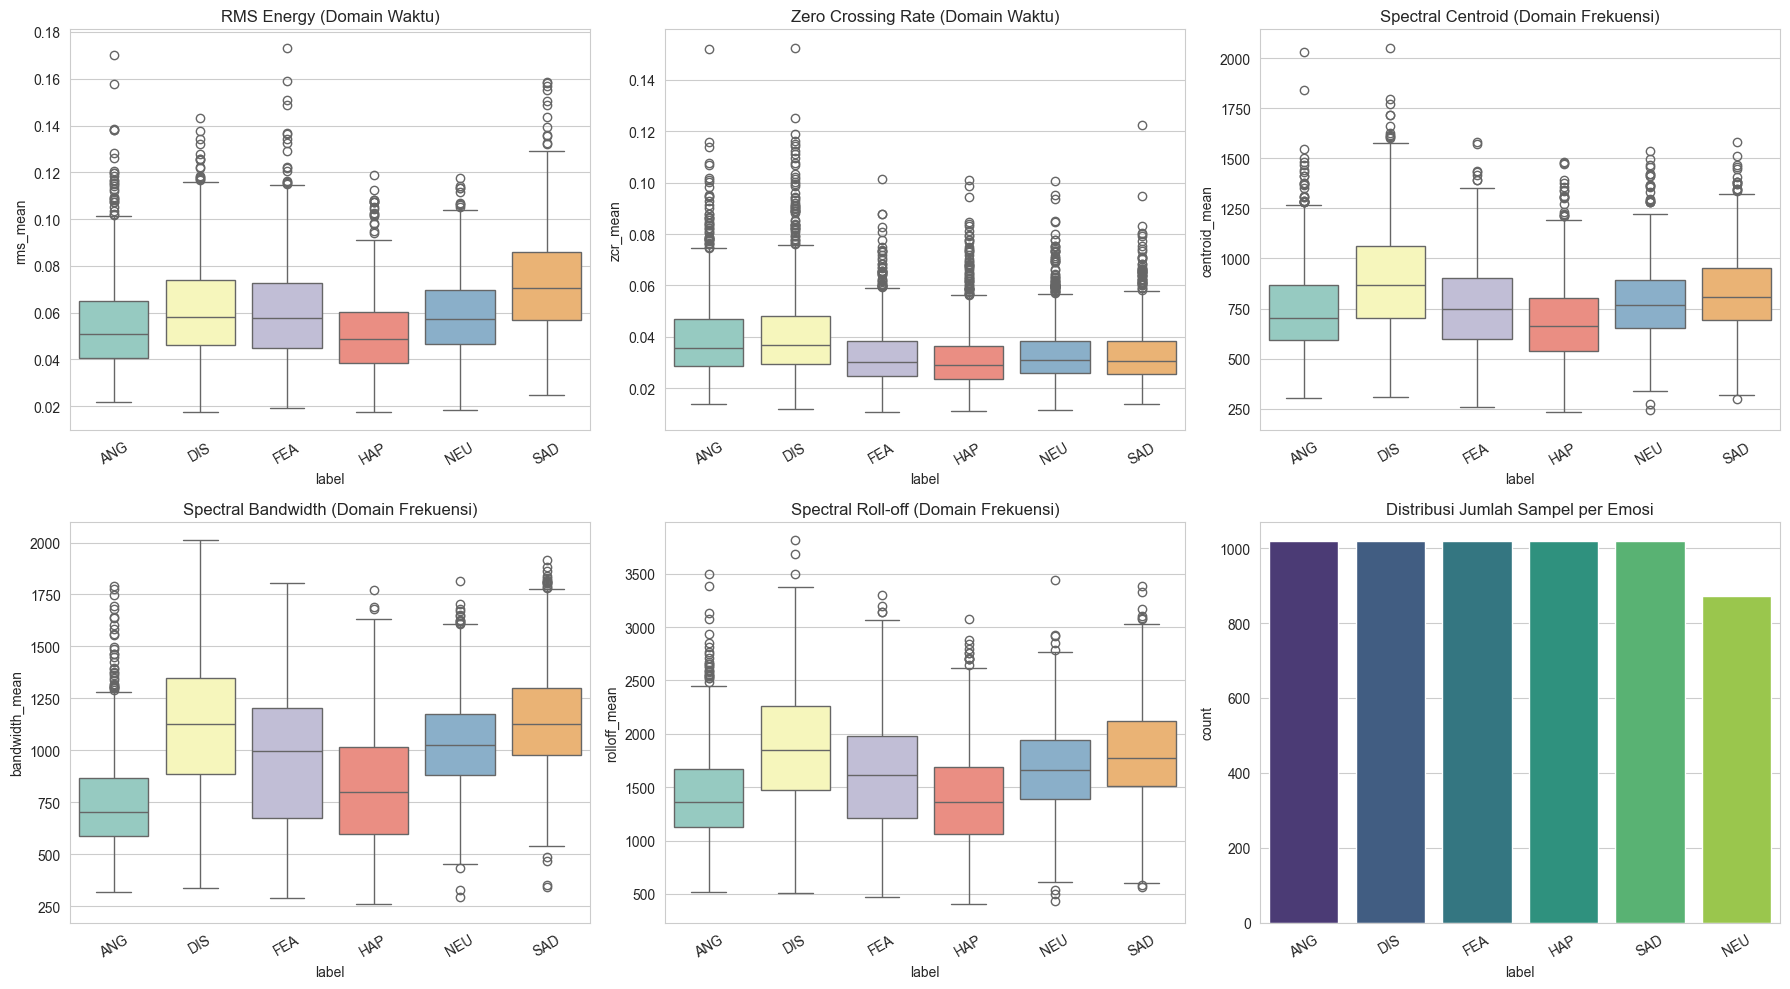


Visualisasi disimpan ke 'visualisasi_fitur_dasar_train.png'

>> Heatmap rata-rata 13 koefisien MFCC per kategori emosi
   Penjelasan: Setiap baris adalah satu kelas emosi, setiap kolom adalah satu koefisien MFCC. Warna berbeda antar baris menunjukkan bahwa pola MFCC memang berbeda-beda untuk tiap emosi -> inilah alasan MFCC sangat berguna untuk klasifikasi emosi.


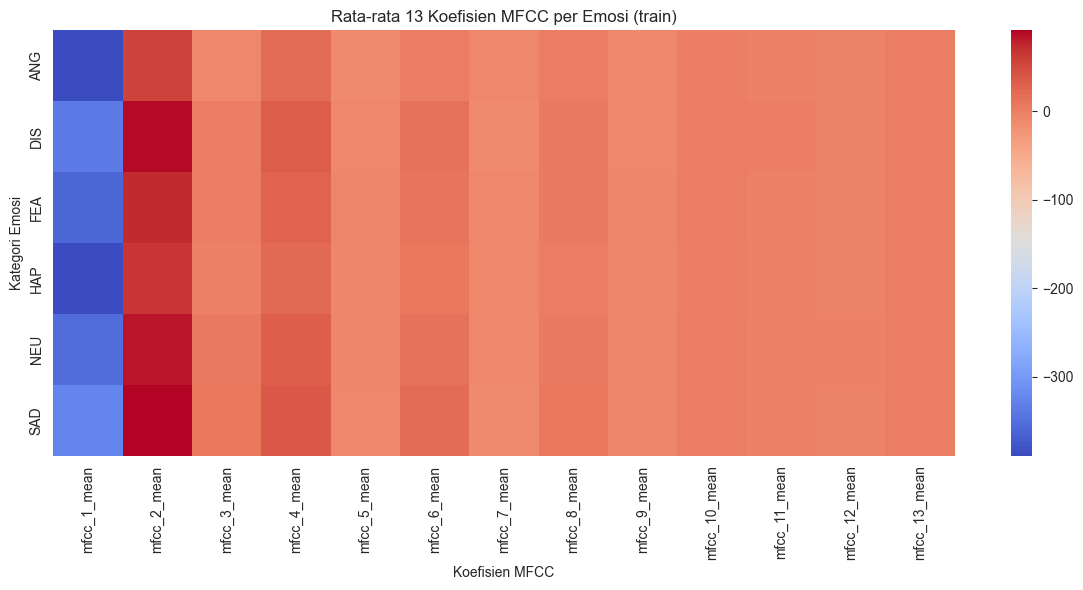


Visualisasi disimpan ke 'heatmap_mfcc_train.png'


In [15]:
def visualize_all_basic_features(df, split_name):
    explain(
        "Boxplot seluruh fitur dasar per kategori emosi",
        "Menampilkan distribusi (median, kuartil, outlier) dari RMS Energy, "
        "Zero Crossing Rate, Spectral Centroid, Bandwidth, dan Roll-off untuk "
        "SETIAP kelas emosi, agar terlihat fitur mana yang paling membedakan "
        "antar emosi."
    )

    fitur_dasar = ["rms_mean", "zcr_mean", "centroid_mean", "bandwidth_mean", "rolloff_mean"]
    judul = ["RMS Energy (Domain Waktu)", "Zero Crossing Rate (Domain Waktu)",
             "Spectral Centroid (Domain Frekuensi)", "Spectral Bandwidth (Domain Frekuensi)",
             "Spectral Roll-off (Domain Frekuensi)"]

    n = len(fitur_dasar)
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    for i, (kolom, title) in enumerate(zip(fitur_dasar, judul)):
        sns.boxplot(data=df, x="label", y=kolom, ax=axes[i], palette="Set3")
        axes[i].set_title(title)
        axes[i].tick_params(axis="x", rotation=30)

    sns.countplot(data=df, x="label", order=df["label"].value_counts().index,
                  ax=axes[n], palette="viridis")
    axes[n].set_title("Distribusi Jumlah Sampel per Emosi")
    axes[n].tick_params(axis="x", rotation=30)

    plt.tight_layout()
    plt.savefig(f"visualisasi_fitur_dasar_{split_name}.png", dpi=150)
    plt.show()
    print(f"\nVisualisasi disimpan ke 'visualisasi_fitur_dasar_{split_name}.png'")


def visualize_mfcc_heatmap(df, split_name):
    explain(
        "Heatmap rata-rata 13 koefisien MFCC per kategori emosi",
        "Setiap baris adalah satu kelas emosi, setiap kolom adalah satu "
        "koefisien MFCC. Warna berbeda antar baris menunjukkan bahwa pola "
        "MFCC memang berbeda-beda untuk tiap emosi -> inilah alasan MFCC "
        "sangat berguna untuk klasifikasi emosi."
    )
    mfcc_cols = [c for c in df.columns if c.startswith("mfcc_") and c.endswith("_mean")]
    mfcc_means = df.groupby("label")[mfcc_cols].mean()

    plt.figure(figsize=(12, 6))
    sns.heatmap(mfcc_means, cmap="coolwarm", annot=False)
    plt.title(f"Rata-rata 13 Koefisien MFCC per Emosi ({split_name})")
    plt.xlabel("Koefisien MFCC")
    plt.ylabel("Kategori Emosi")
    plt.tight_layout()
    plt.savefig(f"heatmap_mfcc_{split_name}.png", dpi=150)
    plt.show()
    print(f"\nVisualisasi disimpan ke 'heatmap_mfcc_{split_name}.png'")


visualize_all_basic_features(df_train, "train")
visualize_mfcc_heatmap(df_train, "train")


>> Waveform & Mel Spectrogram untuk SETIAP kategori emosi
   Penjelasan: Mengambil 1 contoh file dari MASING-MASING kelas emosi (bukan cuma 1 kelas), agar terlihat perbedaan visual bentuk gelombang dan pola spektral antar emosi secara langsung.


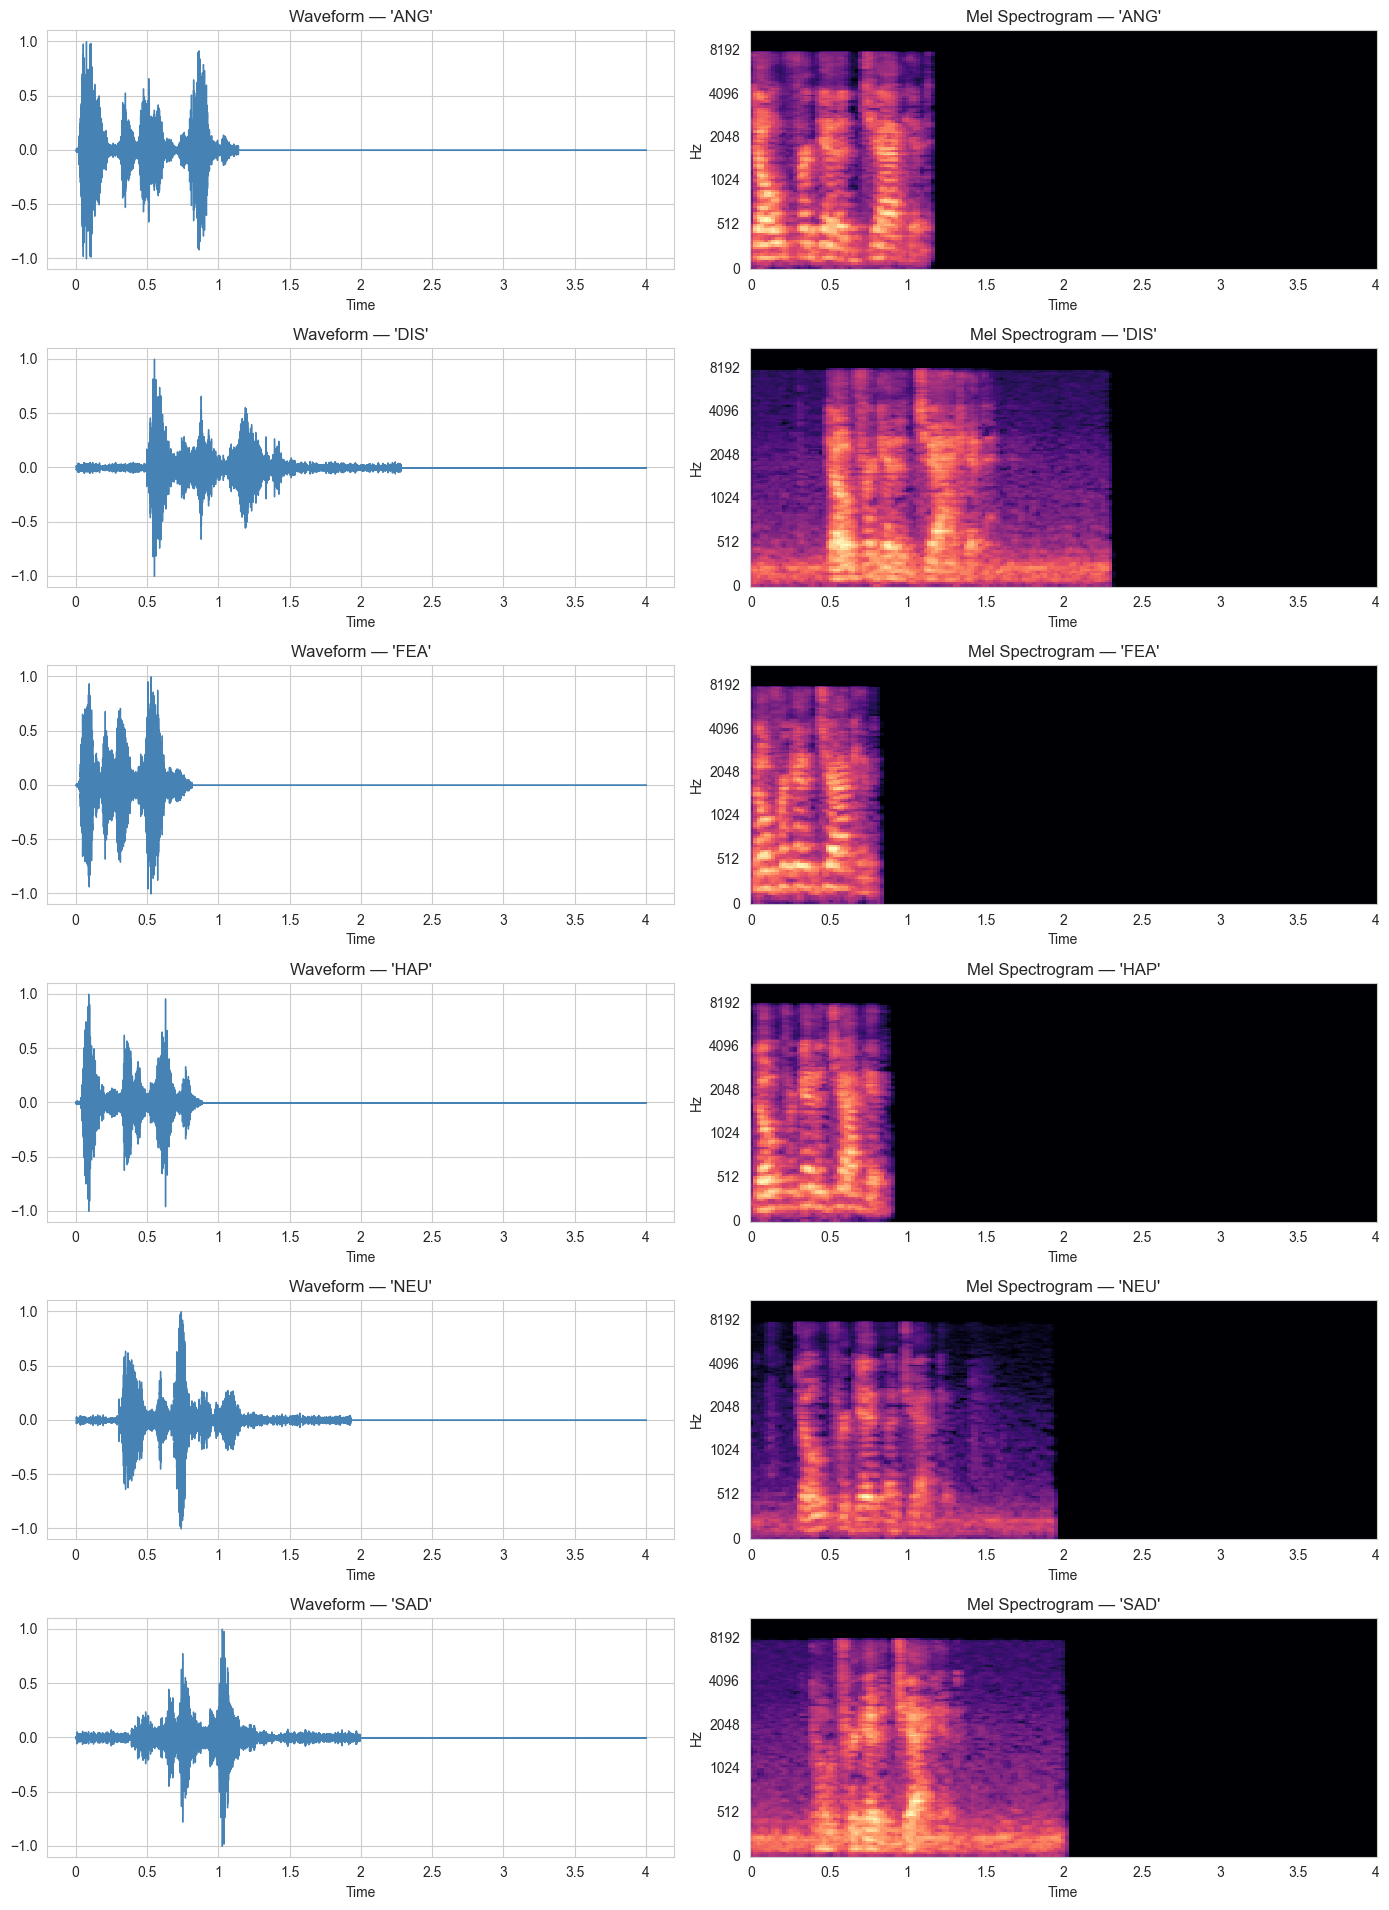


Visualisasi disimpan ke 'visualisasi_semua_kategori_audio.png'


In [16]:
def visualize_all_categories_audio(split_name="train"):
    explain(
        "Waveform & Mel Spectrogram untuk SETIAP kategori emosi",
        "Mengambil 1 contoh file dari MASING-MASING kelas emosi (bukan cuma "
        "1 kelas), agar terlihat perbedaan visual bentuk gelombang dan pola "
        "spektral antar emosi secara langsung."
    )

    folder = os.path.join(BASE_DIR, split_name)
    label_folders = sorted([d for d in os.listdir(folder) if os.path.isdir(os.path.join(folder, d))])

    n_class = len(label_folders)
    fig, axes = plt.subplots(n_class, 2, figsize=(14, 3.2 * n_class))
    if n_class == 1:
        axes = axes.reshape(1, 2)

    for idx, label in enumerate(label_folders):
        files = glob.glob(os.path.join(folder, label, "*.wav"))
        if not files:
            continue
        sample_path = files[0]
        y, sr = load_and_preprocess_audio(sample_path)

        librosa.display.waveshow(y, sr=sr, ax=axes[idx, 0], color="steelblue")
        axes[idx, 0].set_title(f"Waveform — '{label}'")

        mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS)
        mel_db = librosa.power_to_db(mel, ref=np.max)
        librosa.display.specshow(mel_db, sr=sr, x_axis="time", y_axis="mel", ax=axes[idx, 1])
        axes[idx, 1].set_title(f"Mel Spectrogram — '{label}'")

    plt.tight_layout()
    plt.savefig("visualisasi_semua_kategori_audio.png", dpi=150)
    plt.show()
    print("\nVisualisasi disimpan ke 'visualisasi_semua_kategori_audio.png'")

visualize_all_categories_audio("train")

## 4. Training & Evaluasi Model

### 4.1 Muat fitur & tentukan kolom per skenario
Kolom fitur dikelompokkan menjadi tiga skenario sesuai tugas:
- **A. Domain waktu saja** (RMS + ZCR)
- **B. MFCC saja** (MFCC + Delta + Delta-Delta)
- **C. Kombinasi semua fitur** (waktu + frekuensi + MFCC)

In [17]:
def load_tabular_features(path_train, path_test):
    df_train = pd.read_csv(path_train)
    df_test = pd.read_csv(path_test)

    time_cols = [c for c in df_train.columns if c.startswith(("rms_", "zcr_"))]
    freq_cols = [c for c in df_train.columns if c.startswith(("centroid_", "bandwidth_", "rolloff_"))]
    mfcc_cols = [c for c in df_train.columns if "mfcc" in c]

    explain(
        "Jumlah fitur pada masing-masing kelompok skenario",
        "Domain waktu (A) hanya beberapa fitur sederhana, MFCC (B) jumlahnya "
        "paling banyak karena ada 13 koefisien x mean/std x 3 varian "
        "(MFCC, Delta, Delta-Delta), dan Kombinasi (C) menggabungkan semuanya."
    )
    print("Jumlah fitur domain waktu    :", len(time_cols))
    print("Jumlah fitur domain frekuensi:", len(freq_cols))
    print("Jumlah fitur MFCC (+delta)   :", len(mfcc_cols))
    return df_train, df_test, time_cols, freq_cols, mfcc_cols

df_train, df_test, time_cols, freq_cols, mfcc_cols = load_tabular_features(
    "features_train.csv", "features_test.csv"
)


>> Jumlah fitur pada masing-masing kelompok skenario
   Penjelasan: Domain waktu (A) hanya beberapa fitur sederhana, MFCC (B) jumlahnya paling banyak karena ada 13 koefisien x mean/std x 3 varian (MFCC, Delta, Delta-Delta), dan Kombinasi (C) menggabungkan semuanya.
Jumlah fitur domain waktu    : 4
Jumlah fitur domain frekuensi: 6
Jumlah fitur MFCC (+delta)   : 78


### 4.2 Fungsi-fungsi training, evaluasi, dan visualisasi

In [18]:
# ======================================================================
# FUNGSI: prepare_scenario_data
# ----------------------------------------------------------------------
# Tujuan: Menyiapkan X_train, X_test, y_train, y_test untuk satu skenario
# fitur, termasuk standarisasi fitur (penting untuk SVM) dan encoding
# label string emosi menjadi angka.
# ======================================================================
def prepare_scenario_data(df_train, df_test, feature_cols, label_encoder=None):
    X_train = df_train[feature_cols].values
    X_test = df_test[feature_cols].values
    y_train_raw = df_train["label"].values
    y_test_raw = df_test["label"].values

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    if label_encoder is None:
        label_encoder = LabelEncoder()
        label_encoder.fit(y_train_raw)

    y_train = label_encoder.transform(y_train_raw)
    y_test = label_encoder.transform(y_test_raw)
    return X_train_scaled, X_test_scaled, y_train, y_test, label_encoder, scaler

In [19]:
# ======================================================================
# FUNGSI: train_and_evaluate
# ----------------------------------------------------------------------
# Tujuan: Melatih satu model (SVM/RF) lalu menghitung metrik evaluasi:
# accuracy, precision/recall/F1 (macro average), classification report
# per kelas, dan confusion matrix — masing-masing dengan penjelasan makna.
# ======================================================================
def train_and_evaluate(model, X_train, y_train, X_test, y_test, label_encoder, model_name, scenario_name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="macro")
    report = classification_report(y_test, y_pred, target_names=label_encoder.classes_)
    cm = confusion_matrix(y_test, y_pred)

    explain(
        f"Hasil evaluasi {model_name} pada skenario '{scenario_name}'",
        "Accuracy = persentase prediksi benar secara keseluruhan. Precision = "
        "dari semua prediksi suatu kelas, berapa persen yang benar. Recall = "
        "dari semua data aktual suatu kelas, berapa persen yang berhasil "
        "terdeteksi. F1 = rata-rata harmonik precision & recall, dipakai "
        "karena lebih adil saat jumlah data antar kelas tidak seimbang."
    )
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision (macro): {precision:.4f}")
    print(f"Recall    (macro): {recall:.4f}")
    print(f"F1-score  (macro): {f1:.4f}")

    explain(
        "Classification report per kelas",
        "Menunjukkan precision/recall/F1 untuk SETIAP kelas emosi secara "
        "terpisah, agar terlihat kelas mana yang paling sulit dikenali model."
    )
    print(report)

    return {
        "model": model_name, "scenario": scenario_name,
        "accuracy": acc, "precision": precision, "recall": recall, "f1": f1,
        "confusion_matrix": cm, "labels": label_encoder.classes_,
        "trained_model": model,
    }

In [20]:
# ======================================================================
# FUNGSI: plot_confusion_matrix
# ----------------------------------------------------------------------
# Tujuan: Memvisualisasikan confusion matrix sebagai heatmap, agar
# terlihat jelas emosi mana yang sering tertukar dengan emosi lain.
# ======================================================================
def plot_confusion_matrix(result, filename_suffix=""):
    explain(
        f"Confusion Matrix — {result['model']} ({result['scenario']})",
        "Baris = label aktual, kolom = label prediksi. Nilai di luar diagonal "
        "menunjukkan jenis kesalahan (misalnya emosi 'marah' sering diprediksi "
        "sebagai 'senang'), sedangkan nilai di diagonal adalah prediksi yang benar."
    )
    cm = result["confusion_matrix"]
    labels = result["labels"]

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
    plt.title(f"Confusion Matrix: {result['model']} ({result['scenario']})")
    plt.xlabel("Prediksi")
    plt.ylabel("Aktual")
    plt.tight_layout()
    fname = f"confmat_{result['model']}_{result['scenario']}{filename_suffix}.png".replace(" ", "_")
    plt.savefig(fname, dpi=150)
    plt.show()
    print(f"Confusion matrix disimpan ke '{fname}'")

In [21]:
# ======================================================================
# FUNGSI: run_all_scenarios
# ----------------------------------------------------------------------
# Tujuan: Orkestrator utama bagian SVM & Random Forest. Loop terhadap
# 3 skenario fitur (A/B/C) x 2 model (SVM, RF), kumpulkan semua hasil
# evaluasi + simpan scaler/encoder per skenario untuk dipakai ulang
# nanti saat ekspor .pkl.
# ======================================================================
def run_all_scenarios(df_train, df_test, time_cols, freq_cols, mfcc_cols):
    scenarios = {
        "A_DomainWaktu": time_cols,
        "B_MFCC": mfcc_cols,
        "C_Kombinasi": time_cols + freq_cols + mfcc_cols,
    }

    all_results = []
    scalers_per_scenario = {}
    label_encoder = None

    for scenario_name, cols in scenarios.items():
        explain(
            f"Memulai eksperimen skenario {scenario_name}",
            f"Menggunakan {len(cols)} kolom fitur untuk melatih SVM dan Random Forest."
        )

        X_train, X_test, y_train, y_test, label_encoder, scaler = prepare_scenario_data(
            df_train, df_test, cols, label_encoder
        )
        scalers_per_scenario[scenario_name] = (scaler, cols)

        svm_model = SVC(kernel="rbf", C=10, gamma="scale", probability=True)
        rf_model = RandomForestClassifier(n_estimators=200, random_state=42)

        res_svm = train_and_evaluate(svm_model, X_train, y_train, X_test, y_test,
                                      label_encoder, "SVM", scenario_name)
        res_rf = train_and_evaluate(rf_model, X_train, y_train, X_test, y_test,
                                     label_encoder, "RandomForest", scenario_name)

        plot_confusion_matrix(res_svm)
        plot_confusion_matrix(res_rf)

        all_results.append(res_svm)
        all_results.append(res_rf)

    return all_results, scalers_per_scenario, label_encoder

### 4.3 Jalankan SVM & Random Forest untuk 3 skenario


>> Memulai eksperimen skenario A_DomainWaktu
   Penjelasan: Menggunakan 4 kolom fitur untuk melatih SVM dan Random Forest.

>> Hasil evaluasi SVM pada skenario 'A_DomainWaktu'
   Penjelasan: Accuracy = persentase prediksi benar secara keseluruhan. Precision = dari semua prediksi suatu kelas, berapa persen yang benar. Recall = dari semua data aktual suatu kelas, berapa persen yang berhasil terdeteksi. F1 = rata-rata harmonik precision & recall, dipakai karena lebih adil saat jumlah data antar kelas tidak seimbang.
Accuracy : 0.3505
Precision (macro): 0.3191
Recall    (macro): 0.3480
F1-score  (macro): 0.3175

>> Classification report per kelas
   Penjelasan: Menunjukkan precision/recall/F1 untuk SETIAP kelas emosi secara terpisah, agar terlihat kelas mana yang paling sulit dikenali model.
              precision    recall  f1-score   support

         ANG       0.37      0.58      0.45       252
         DIS       0.33      0.30      0.32       252
         FEA       0.18      0.04    

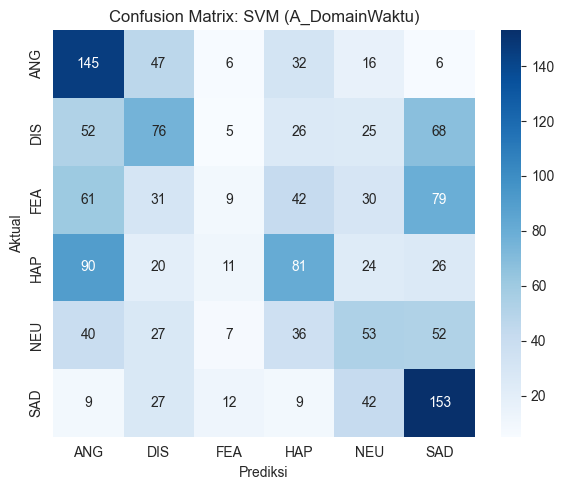

Confusion matrix disimpan ke 'confmat_SVM_A_DomainWaktu.png'

>> Confusion Matrix — RandomForest (A_DomainWaktu)
   Penjelasan: Baris = label aktual, kolom = label prediksi. Nilai di luar diagonal menunjukkan jenis kesalahan (misalnya emosi 'marah' sering diprediksi sebagai 'senang'), sedangkan nilai di diagonal adalah prediksi yang benar.


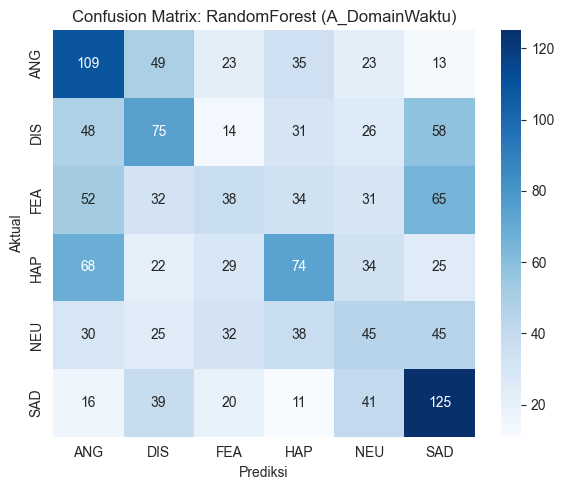

Confusion matrix disimpan ke 'confmat_RandomForest_A_DomainWaktu.png'

>> Memulai eksperimen skenario B_MFCC
   Penjelasan: Menggunakan 78 kolom fitur untuk melatih SVM dan Random Forest.

>> Hasil evaluasi SVM pada skenario 'B_MFCC'
   Penjelasan: Accuracy = persentase prediksi benar secara keseluruhan. Precision = dari semua prediksi suatu kelas, berapa persen yang benar. Recall = dari semua data aktual suatu kelas, berapa persen yang berhasil terdeteksi. F1 = rata-rata harmonik precision & recall, dipakai karena lebih adil saat jumlah data antar kelas tidak seimbang.
Accuracy : 0.4617
Precision (macro): 0.4568
Recall    (macro): 0.4589
F1-score  (macro): 0.4474

>> Classification report per kelas
   Penjelasan: Menunjukkan precision/recall/F1 untuk SETIAP kelas emosi secara terpisah, agar terlihat kelas mana yang paling sulit dikenali model.
              precision    recall  f1-score   support

         ANG       0.49      0.85      0.62       252
         DIS       0.42      0.41 

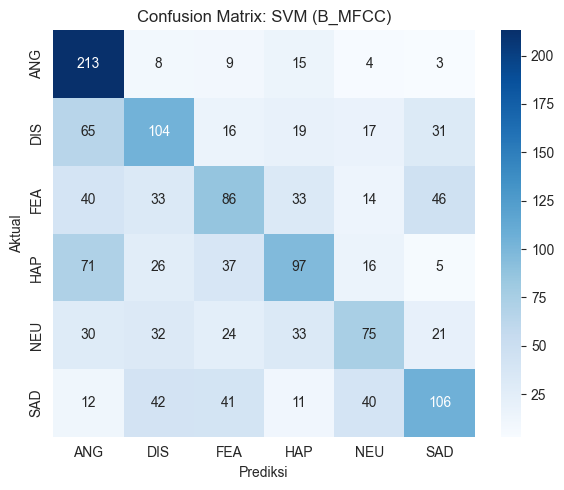

Confusion matrix disimpan ke 'confmat_SVM_B_MFCC.png'

>> Confusion Matrix — RandomForest (B_MFCC)
   Penjelasan: Baris = label aktual, kolom = label prediksi. Nilai di luar diagonal menunjukkan jenis kesalahan (misalnya emosi 'marah' sering diprediksi sebagai 'senang'), sedangkan nilai di diagonal adalah prediksi yang benar.


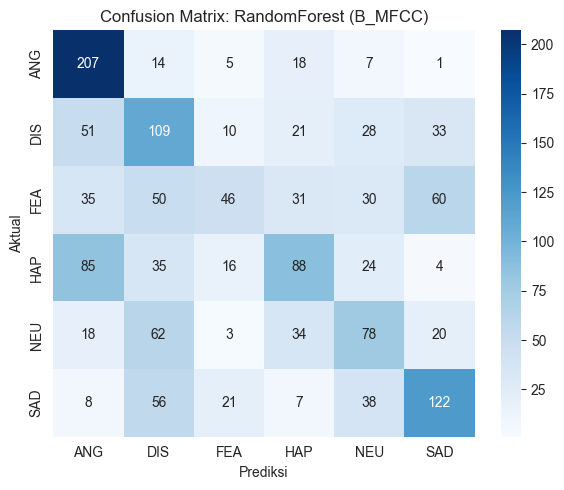

Confusion matrix disimpan ke 'confmat_RandomForest_B_MFCC.png'

>> Memulai eksperimen skenario C_Kombinasi
   Penjelasan: Menggunakan 88 kolom fitur untuk melatih SVM dan Random Forest.

>> Hasil evaluasi SVM pada skenario 'C_Kombinasi'
   Penjelasan: Accuracy = persentase prediksi benar secara keseluruhan. Precision = dari semua prediksi suatu kelas, berapa persen yang benar. Recall = dari semua data aktual suatu kelas, berapa persen yang berhasil terdeteksi. F1 = rata-rata harmonik precision & recall, dipakai karena lebih adil saat jumlah data antar kelas tidak seimbang.
Accuracy : 0.4692
Precision (macro): 0.4654
Recall    (macro): 0.4668
F1-score  (macro): 0.4561

>> Classification report per kelas
   Penjelasan: Menunjukkan precision/recall/F1 untuk SETIAP kelas emosi secara terpisah, agar terlihat kelas mana yang paling sulit dikenali model.
              precision    recall  f1-score   support

         ANG       0.50      0.84      0.63       252
         DIS       0.46      0.

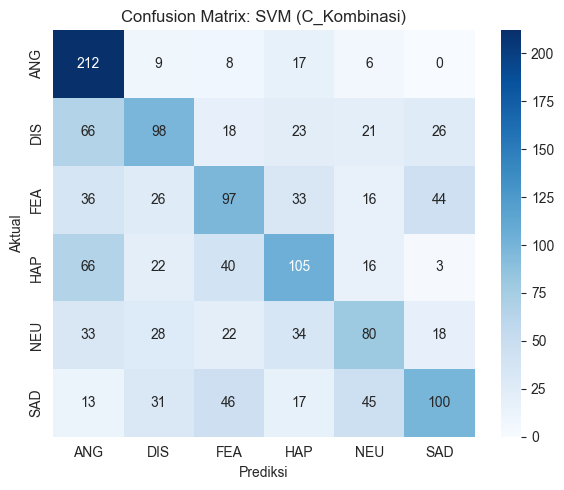

Confusion matrix disimpan ke 'confmat_SVM_C_Kombinasi.png'

>> Confusion Matrix — RandomForest (C_Kombinasi)
   Penjelasan: Baris = label aktual, kolom = label prediksi. Nilai di luar diagonal menunjukkan jenis kesalahan (misalnya emosi 'marah' sering diprediksi sebagai 'senang'), sedangkan nilai di diagonal adalah prediksi yang benar.


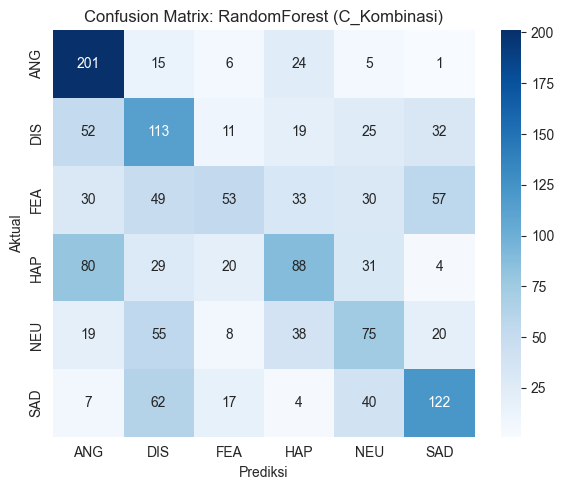

Confusion matrix disimpan ke 'confmat_RandomForest_C_Kombinasi.png'


In [22]:
all_results, scalers_per_scenario, label_encoder = run_all_scenarios(
    df_train, df_test, time_cols, freq_cols, mfcc_cols
)

In [23]:
# ======================================================================
# FUNGSI: build_comparison_table
# ----------------------------------------------------------------------
# Tujuan: Merangkum seluruh hasil (semua model x semua skenario) ke
# dalam satu tabel DataFrame yang rapi untuk laporan.
# ======================================================================
def build_comparison_table(all_results):
    rows = []
    for r in all_results:
        rows.append({
            "Model": r["model"], "Skenario": r["scenario"],
            "Accuracy": round(r["accuracy"], 4),
            "Precision": round(r["precision"], 4),
            "Recall": round(r["recall"], 4),
            "F1-score": round(r["f1"], 4),
        })
    df_compare = pd.DataFrame(rows)

    explain(
        "Tabel perbandingan seluruh skenario & model",
        "Bandingkan baris-baris ini untuk melihat skenario fitur mana (A, B, "
        "atau C) dan model mana (SVM atau RF) yang memberi performa terbaik."
    )
    display(df_compare)
    df_compare.to_csv("tabel_perbandingan_skenario.csv", index=False)
    print("\nTabel disimpan ke 'tabel_perbandingan_skenario.csv'")
    return df_compare

df_compare = build_comparison_table(all_results)


>> Tabel perbandingan seluruh skenario & model
   Penjelasan: Bandingkan baris-baris ini untuk melihat skenario fitur mana (A, B, atau C) dan model mana (SVM atau RF) yang memberi performa terbaik.


,Model,Skenario,Accuracy,Precision,Recall,F1-score
0,SVM,A_DomainWaktu,0.3505,0.3191,0.3480,0.3175
1,RandomForest,A_DomainWaktu,0.3159,0.3042,0.3133,0.3044
2,SVM,B_MFCC,0.4617,0.4568,0.4589,0.4474
3,RandomForest,B_MFCC,0.4407,0.4389,0.4388,0.4211
4,SVM,C_Kombinasi,0.4692,0.4654,0.4668,0.4561
5,RandomForest,C_Kombinasi,0.4420,0.4393,0.4398,0.4249



Tabel disimpan ke 'tabel_perbandingan_skenario.csv'



>> Grafik perbandingan Accuracy & F1-score antar skenario
   Penjelasan: Memudahkan melihat secara visual skenario mana yang paling unggul, tanpa harus membaca tabel angka satu per satu.


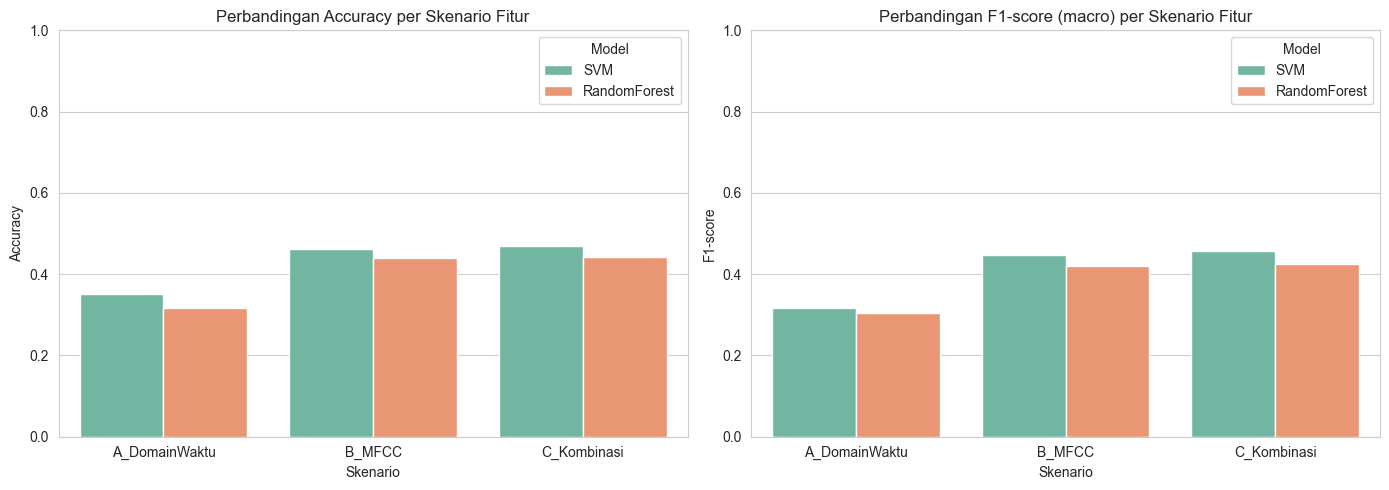


Grafik perbandingan disimpan ke 'perbandingan_skenario.png'


In [24]:
# ======================================================================
# FUNGSI: plot_comparison
# ----------------------------------------------------------------------
# Tujuan: Bar chart yang membandingkan Accuracy dan F1-score untuk setiap
# kombinasi (Model x Skenario).
# ======================================================================
def plot_comparison(df_compare):
    explain(
        "Grafik perbandingan Accuracy & F1-score antar skenario",
        "Memudahkan melihat secara visual skenario mana yang paling unggul, "
        "tanpa harus membaca tabel angka satu per satu."
    )
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.barplot(data=df_compare, x="Skenario", y="Accuracy", hue="Model", ax=axes[0], palette="Set2")
    axes[0].set_title("Perbandingan Accuracy per Skenario Fitur")
    axes[0].set_ylim(0, 1)

    sns.barplot(data=df_compare, x="Skenario", y="F1-score", hue="Model", ax=axes[1], palette="Set2")
    axes[1].set_title("Perbandingan F1-score (macro) per Skenario Fitur")
    axes[1].set_ylim(0, 1)

    plt.tight_layout()
    plt.savefig("perbandingan_skenario.png", dpi=150)
    plt.show()
    print("\nGrafik perbandingan disimpan ke 'perbandingan_skenario.png'")

plot_comparison(df_compare)

### 4.4 CNN pada Mel Spectrogram
Bagian ini melatih CNN sederhana (2 blok Conv2D+MaxPooling -> Dense -> Softmax)
menggunakan Mel Spectrogram (hasil data yang sudah dipreprocessing) sebagai
input gambar 1-channel.

In [34]:
# ======================================================================
# FUNGSI: build_and_train_cnn
# ----------------------------------------------------------------------
# Tujuan: Membangun & melatih CNN untuk klasifikasi emosi dari Mel
# Spectrogram. epochs=50 hanya batas MAKSIMUM — EarlyStopping akan
# menghentikan training lebih awal begitu val_loss tidak membaik lagi.
#
# Versi ini ditambah beberapa teknik ANTI-OVERFITTING karena dataset audio
# relatif kecil dibanding kapasitas CNN:
#   - Dropout lebih agresif (0.3 -> 0.4-0.5) dan ditambah di lebih banyak layer
#   - L2 regularization pada layer Conv2D & Dense (menahan bobot agar tidak
#     terlalu besar/'menghafal' data training)
#   - BatchNormalization agar training lebih stabil
# ======================================================================
def build_and_train_cnn(mel_train, labels_train, mel_test, labels_test, epochs=50):
    import tensorflow as tf
    from tensorflow.keras import layers, models, regularizers

    le_cnn = LabelEncoder()
    y_train = le_cnn.fit_transform(labels_train)
    y_test = le_cnn.transform(labels_test)

    X_train = (mel_train - mel_train.min()) / (mel_train.max() - mel_train.min())
    X_test = (mel_test - mel_test.min()) / (mel_test.max() - mel_test.min())
    X_train = X_train[..., np.newaxis]
    X_test = X_test[..., np.newaxis]

    n_classes = len(le_cnn.classes_)
    input_shape = X_train.shape[1:]
    L2 = regularizers.l2(1e-4)   # kekuatan regularisasi L2, bisa diperbesar (1e-3) jika overfitting masih parah

    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, (3, 3), activation="relu", padding="same", kernel_regularizer=L2),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),

        layers.Conv2D(64, (3, 3), activation="relu", padding="same", kernel_regularizer=L2),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.4),

        layers.Flatten(),
        layers.Dense(128, activation="relu", kernel_regularizer=L2),
        layers.Dropout(0.5),
        layers.Dense(n_classes, activation="softmax"),
    ])

    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

    explain(
        "Ringkasan arsitektur CNN (versi anti-overfitting)",
        "Dibandingkan versi sebelumnya, di sini ditambahkan BatchNormalization "
        "(menstabilkan training), Dropout di lebih banyak layer dengan rate "
        "lebih tinggi (0.3/0.4/0.5), dan L2 regularization pada Conv2D & Dense "
        "agar bobot tidak tumbuh terlalu besar (yang biasanya jadi tanda model "
        "'menghafal' data training)."
    )
    model.summary()

    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=5, restore_best_weights=True
    )

    history = model.fit(X_train, y_train, validation_data=(X_test, y_test),
                         epochs=epochs, batch_size=32, verbose=1,
                         callbacks=[early_stop])

    y_pred = np.argmax(model.predict(X_test), axis=1)
    acc = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="macro")

    explain(
        "Hasil evaluasi CNN pada data test",
        "Bandingkan angka-angka ini dengan hasil SVM/RF skenario kombinasi (C), "
        "dan bandingkan juga gap antara train accuracy vs validation accuracy "
        "pada grafik training history -> gap yang lebih kecil dari sebelumnya "
        "berarti overfitting sudah berkurang."
    )
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision (macro): {precision:.4f}")
    print(f"Recall    (macro): {recall:.4f}")
    print(f"F1-score  (macro): {f1:.4f}")
    print(classification_report(y_test, y_pred, target_names=le_cnn.classes_))

    cm = confusion_matrix(y_test, y_pred)
    plot_confusion_matrix({"model": "CNN", "scenario": "MelSpectrogram",
                            "confusion_matrix": cm, "labels": le_cnn.classes_})

    plot_training_history(history)

    return {"model": "CNN", "scenario": "MelSpectrogram",
            "accuracy": acc, "precision": precision, "recall": recall, "f1": f1,
            "trained_model": model, "label_encoder": le_cnn}

In [35]:
# ======================================================================
# FUNGSI: plot_training_history
# ----------------------------------------------------------------------
# Tujuan: Memvisualisasikan kurva loss dan accuracy CNN selama training
# (train vs validation per epoch), guna memeriksa indikasi overfitting.
# ======================================================================
def plot_training_history(history):
    explain(
        "Kurva training history CNN",
        "Jika 'Validation' mulai memburuk (loss naik / accuracy turun) "
        "sementara 'Train' masih membaik, itu tanda overfitting. "
        "EarlyStopping otomatis menghentikan training sebelum kondisi ini parah."
    )
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history.history["accuracy"], label="Train")
    axes[0].plot(history.history["val_accuracy"], label="Validation")
    axes[0].set_title("Akurasi CNN per Epoch")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    axes[1].plot(history.history["loss"], label="Train")
    axes[1].plot(history.history["val_loss"], label="Validation")
    axes[1].set_title("Loss CNN per Epoch")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig("cnn_training_history.png", dpi=150)
    plt.show()
    print("\nGrafik training history CNN disimpan ke 'cnn_training_history.png'")

In [36]:
mel_train = np.load("melspec_train.npy")
mel_test = np.load("melspec_test.npy")
labels_train_arr = np.load("labels_train.npy", allow_pickle=True)
labels_test_arr = np.load("labels_test.npy", allow_pickle=True)

cnn_result = build_and_train_cnn(mel_train, labels_train_arr, mel_test, labels_test_arr, epochs=45)


>> Ringkasan arsitektur CNN (versi anti-overfitting)
   Penjelasan: Dibandingkan versi sebelumnya, di sini ditambahkan BatchNormalization (menstabilkan training), Dropout di lebih banyak layer dengan rate lebih tinggi (0.3/0.4/0.5), dan L2 regularization pada Conv2D & Dense agar bobot tidak tumbuh terlalu besar (yang biasanya jadi tanda model 'menghafal' data training).


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 128, 174, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 174, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 64, 87, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64, 87, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 64, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 87, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 32, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 88064)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │    11,272,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,292,294 (43.08 MB)

 Trainable params: 11,292,102 (43.08 MB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/45
187/187 ━━━━━━━━━━━━━━━━━━━━ 130s 679ms/step - accuracy: 0.1763 - loss: 3.6112 - val_accuracy: 0.1458 - val_loss: 101.7613
Epoch 2/45
187/187 ━━━━━━━━━━━━━━━━━━━━ 125s 667ms/step - accuracy: 0.1736 - loss: 1.8603 - val_accuracy: 0.1458 - val_loss: 74.2711
Epoch 3/45
100/187 ━━━━━━━━━━━━━━━━━━━━ 56s 652ms/step - accuracy: 0.1624 - loss: 1.8622

KeyboardInterrupt: 

### 4.5 Tabel Perbandingan Akhir (SVM, Random Forest, CNN)

In [29]:
df_final = pd.concat([df_compare, pd.DataFrame([{
    "Model": cnn_result["model"], "Skenario": cnn_result["scenario"],
    "Accuracy": round(cnn_result["accuracy"], 4),
    "Precision": round(cnn_result["precision"], 4),
    "Recall": round(cnn_result["recall"], 4),
    "F1-score": round(cnn_result["f1"], 4),
}])], ignore_index=True)

explain(
    "Tabel perbandingan FINAL termasuk CNN",
    "Tabel ini adalah ringkasan akhir untuk bagian Analisis laporan: "
    "membandingkan domain waktu saja vs MFCC saja vs kombinasi semua fitur, "
    "untuk SVM dan RF, lalu dibandingkan lagi dengan CNN berbasis Mel Spectrogram."
)
display(df_final)
df_final.to_csv("tabel_perbandingan_final.csv", index=False)
print("\nTabel final disimpan ke 'tabel_perbandingan_final.csv'")


>> Tabel perbandingan FINAL termasuk CNN
   Penjelasan: Tabel ini adalah ringkasan akhir untuk bagian Analisis laporan: membandingkan domain waktu saja vs MFCC saja vs kombinasi semua fitur, untuk SVM dan RF, lalu dibandingkan lagi dengan CNN berbasis Mel Spectrogram.


,Model,Skenario,Accuracy,Precision,Recall,F1-score
0,SVM,A_DomainWaktu,0.3505,0.3191,0.3480,0.3175
1,RandomForest,A_DomainWaktu,0.3159,0.3042,0.3133,0.3044
2,SVM,B_MFCC,0.4617,0.4568,0.4589,0.4474
3,RandomForest,B_MFCC,0.4407,0.4389,0.4388,0.4211
4,SVM,C_Kombinasi,0.4692,0.4654,0.4668,0.4561
5,RandomForest,C_Kombinasi,0.4420,0.4393,0.4398,0.4249
6,CNN,MelSpectrogram,0.4549,0.4415,0.4553,0.4391



Tabel final disimpan ke 'tabel_perbandingan_final.csv'


## 5. Ekspor Model ke `.pkl` untuk Streamlit App
Tahap akhir: menyimpan model terbaik beserta `scaler` dan `label_encoder`
yang dibutuhkan agar nanti aplikasi Streamlit bisa memuat ulang model dan
melakukan prediksi terhadap file audio baru tanpa perlu training ulang.

Yang disimpan:
- Model SVM & Random Forest terbaik untuk skenario **C (Kombinasi)** — ini
  skenario yang dipakai di aplikasi karena memanfaatkan seluruh jenis fitur.
- `StandardScaler` skenario C (wajib dipakai ulang agar skala fitur sama
  seperti saat training).
- `LabelEncoder` agar hasil prediksi angka bisa diubah balik ke nama emosi.
- Daftar nama kolom fitur skenario C, agar Streamlit tahu fitur apa & dalam
  urutan apa yang harus dihitung dari file audio yang diunggah user.

> **Catatan:** Model CNN tidak disimpan ke `.pkl` karena format itu tidak
> didesain untuk model TensorFlow/Keras. CNN disimpan terpisah dengan
> format aslinya (`.keras`), namun tetap bisa dimuat di Streamlit.

In [30]:
# ======================================================================
# FUNGSI: export_models_for_streamlit
# ----------------------------------------------------------------------
# Tujuan: Mengambil model SVM & RF dari skenario 'C_Kombinasi' (karena ini
# yang memakai seluruh fitur, paling representatif untuk aplikasi umum),
# beserta scaler, label encoder, dan daftar kolom fiturnya, lalu menyimpan
# semuanya ke file .pkl agar bisa langsung di-load oleh aplikasi Streamlit
# memakai joblib.load() atau pickle.load().
# ======================================================================
def export_models_for_streamlit(all_results, scalers_per_scenario, label_encoder,
                                  scenario_used="C_Kombinasi"):
    svm_c = next(r for r in all_results if r["model"] == "SVM" and r["scenario"] == scenario_used)
    rf_c = next(r for r in all_results if r["model"] == "RandomForest" and r["scenario"] == scenario_used)
    scaler_c, feature_cols_c = scalers_per_scenario[scenario_used]

    bundle = {
        "svm_model": svm_c["trained_model"],
        "rf_model": rf_c["trained_model"],
        "scaler": scaler_c,
        "label_encoder": label_encoder,
        "feature_columns": feature_cols_c,
        "scenario": scenario_used,
        "config": {
            "SR": SR, "N_MFCC": N_MFCC, "N_MELS": N_MELS,
            "MAX_PAD_LEN": MAX_PAD_LEN, "FIXED_DURATION": FIXED_DURATION, "TOP_DB": TOP_DB,
        },
    }

    with open("model_bundle.pkl", "wb") as f:
        pickle.dump(bundle, f)

    # Disimpan juga dengan joblib (umum dipakai untuk model scikit-learn,
    # lebih efisien untuk array numpy besar di dalam model RandomForest)
    joblib.dump(bundle, "model_bundle.joblib.pkl")

    explain(
        "File model_bundle.pkl berhasil disimpan",
        "File ini berisi SVM, Random Forest, scaler, label encoder, dan daftar "
        "kolom fitur skenario kombinasi. Di Streamlit, cukup load file ini, "
        "ekstrak fitur dari audio baru dengan kolom yang SAMA URUTANNYA, lalu "
        "panggil scaler.transform() sebelum model.predict()."
    )
    print("Disimpan ke 'model_bundle.pkl' dan 'model_bundle.joblib.pkl'")
    print("Isi bundle:", list(bundle.keys()))
    print(f"Jumlah kolom fitur yang dipakai: {len(feature_cols_c)}")

    return bundle

bundle = export_models_for_streamlit(all_results, scalers_per_scenario, label_encoder)


>> File model_bundle.pkl berhasil disimpan
   Penjelasan: File ini berisi SVM, Random Forest, scaler, label encoder, dan daftar kolom fitur skenario kombinasi. Di Streamlit, cukup load file ini, ekstrak fitur dari audio baru dengan kolom yang SAMA URUTANNYA, lalu panggil scaler.transform() sebelum model.predict().
Disimpan ke 'model_bundle.pkl' dan 'model_bundle.joblib.pkl'
Isi bundle: ['svm_model', 'rf_model', 'scaler', 'label_encoder', 'feature_columns', 'scenario', 'config']
Jumlah kolom fitur yang dipakai: 88


In [31]:
# ======================================================================
# Simpan CNN secara terpisah (format native Keras, bukan .pkl)
# ======================================================================
cnn_result["trained_model"].save("cnn_model.keras")

explain(
    "Model CNN disimpan ke 'cnn_model.keras'",
    "Format ini menyimpan arsitektur + bobot CNN secara lengkap. Di Streamlit, "
    "model ini dimuat dengan tensorflow.keras.models.load_model('cnn_model.keras')."
)

with open("cnn_label_encoder.pkl", "wb") as f:
    pickle.dump(cnn_result["label_encoder"], f)

print("Label encoder CNN disimpan ke 'cnn_label_encoder.pkl'")


>> Model CNN disimpan ke 'cnn_model.keras'
   Penjelasan: Format ini menyimpan arsitektur + bobot CNN secara lengkap. Di Streamlit, model ini dimuat dengan tensorflow.keras.models.load_model('cnn_model.keras').
Label encoder CNN disimpan ke 'cnn_label_encoder.pkl'


### 5.1 Contoh Cara Memuat `model_bundle.pkl` di Aplikasi Streamlit
Cuplikan kode berikut bisa langsung dipakai sebagai kerangka `app.py`.
Bagian ekstraksi fitur HARUS identik dengan fungsi-fungsi preprocessing &
ekstraksi fitur pada notebook ini, agar urutan dan skala fiturnya cocok
dengan yang dipelajari model saat training.

In [32]:
contoh_kode_streamlit = '''
import streamlit as st
import pickle
import numpy as np
import librosa

with open("model_bundle.pkl", "rb") as f:
    bundle = pickle.load(f)

svm_model = bundle["svm_model"]
rf_model = bundle["rf_model"]
scaler = bundle["scaler"]
label_encoder = bundle["label_encoder"]
feature_columns = bundle["feature_columns"]
config = bundle["config"]

st.title("Speech Emotion Recognition")
uploaded_file = st.file_uploader("Upload file audio (.wav)", type=["wav"])

if uploaded_file is not None:
    y, sr = librosa.load(uploaded_file, sr=config["SR"])
    # --> panggil ulang fungsi preprocessing & ekstraksi fitur yang SAMA
    # seperti di notebook, lalu susun nilai sesuai urutan feature_columns
    # fitur_dict = {...}
    # X = np.array([[fitur_dict[c] for c in feature_columns]])
    # X_scaled = scaler.transform(X)
    # pred = rf_model.predict(X_scaled)
    # emosi = label_encoder.inverse_transform(pred)[0]
    # st.write(f"Prediksi emosi: {emosi}")
'''
print(contoh_kode_streamlit)


import streamlit as st
import pickle
import numpy as np
import librosa

with open("model_bundle.pkl", "rb") as f:
    bundle = pickle.load(f)

svm_model = bundle["svm_model"]
rf_model = bundle["rf_model"]
scaler = bundle["scaler"]
label_encoder = bundle["label_encoder"]
feature_columns = bundle["feature_columns"]
config = bundle["config"]

st.title("Speech Emotion Recognition")
uploaded_file = st.file_uploader("Upload file audio (.wav)", type=["wav"])

if uploaded_file is not None:
    y, sr = librosa.load(uploaded_file, sr=config["SR"])
    # --> panggil ulang fungsi preprocessing & ekstraksi fitur yang SAMA
    # seperti di notebook, lalu susun nilai sesuai urutan feature_columns
    # fitur_dict = {...}
    # X = np.array([[fitur_dict[c] for c in feature_columns]])
    # X_scaled = scaler.transform(X)
    # pred = rf_model.predict(X_scaled)
    # emosi = label_encoder.inverse_transform(pred)[0]
    # st.write(f"Prediksi emosi: {emosi}")



## 6. Analisis
Gunakan tabel dan grafik di atas untuk membahas:
1. **Domain waktu saja (A)** — biasanya akurasi paling rendah, karena RMS & ZCR hanya
   menangkap intensitas/kekasaran sinyal, bukan karakteristik timbre suara.
2. **MFCC saja (B)** — biasanya jauh lebih baik dari (A), karena MFCC menangkap
   warna suara yang berkorelasi kuat dengan ekspresi emosi.
3. **Kombinasi semua fitur (C)** — biasanya performa terbaik atau setara dengan (B),
   karena menambahkan informasi domain frekuensi sebagai pelengkap MFCC.
4. **CNN pada Mel Spectrogram** — bandingkan dengan SVM/RF: apakah CNN unggul karena
   bisa mempelajari pola spektral-temporal secara langsung tanpa perlu fitur buatan
   tangan (hand-crafted features)?
5. **Efek preprocessing** — diskusikan apakah trimming silence dan normalisasi
   amplitudo membantu menstabilkan nilai fitur antar aktor/rekaman.

Lengkapi analisis dengan menyebutkan emosi-emosi yang paling sering tertukar
berdasarkan confusion matrix di atas.